In [ ]:
!pip install -q transformers peft bitsandbytes accelerate datasets sentencepiece triton

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 10.7 MB/s eta 0:00:00


In [ ]:
import torch
import pandas as pd
import numpy as np

from dataclasses import dataclass
from typing import Dict, List, Iterator
from sklearn.model_selection import KFold
from torch.utils.data import Dataset, DataLoader, Sampler

from transformers import (
    MBart50TokenizerFast,
    MBartForConditionalGeneration,
    Trainer,
    TrainingArguments,
    BitsAndBytesConfig,
)

from peft import LoraConfig, get_peft_model, TaskType

In [ ]:
@dataclass
class Config:
    model_name: str = "facebook/mbart-large-50"
    source_lang: str = "bn_IN"
    target_lang: str = "bn_IN"

    max_length: int = 256
    batch_size: int = 2
    grad_accum: int = 8
    lr: float = 2e-4
    epochs: int = 3

    human_ratio: float = 0.20  # HARD constraint
    use_4bit: bool = True

    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.05


In [ ]:
human_df = pd.read_csv("/content/human.csv")
synth_df = pd.read_csv("/content/synthetic.csv")

assert set(human_df.columns) == {"text", "gloss"}
assert set(synth_df.columns) == {"text", "gloss"}

print(f"Human: {len(human_df)} | Synthetic: {len(synth_df)}")

Human: 1000 | Synthetic: 4000


In [ ]:
class BanglaGlossDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        tokenizer: MBart50TokenizerFast,
        max_length: int,
        src_lang: str,
        tgt_lang: str,
    ):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.src_lang = src_lang
        self.tgt_lang = tgt_lang

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row = self.df.iloc[idx]

        self.tokenizer.src_lang = self.src_lang
        model_inputs = self.tokenizer(
            row["text"],
            max_length=self.max_length,
            truncation=True,
        )

        with self.tokenizer.as_target_tokenizer():
            labels = self.tokenizer(
                row["gloss"],
                max_length=self.max_length,
                truncation=True,
            )

        model_inputs["labels"] = labels["input_ids"]
        return {k: torch.tensor(v) for k, v in model_inputs.items()}


In [ ]:
class MixedRatioSampler(Sampler[int]):
    def __init__(
        self,
        human_size: int,
        synth_size: int,
        human_ratio: float,
        epoch_size: int,
        seed: int = 42,
    ):
        self.human_size = human_size
        self.synth_size = synth_size
        self.human_ratio = human_ratio
        self.epoch_size = epoch_size
        self.rng = np.random.default_rng(seed)

    def __iter__(self) -> Iterator[int]:
        human_count = int(self.epoch_size * self.human_ratio)
        synth_count = self.epoch_size - human_count

        human_indices = self.rng.choice(
            self.human_size, size=human_count, replace=True
        )

        synth_indices = self.rng.choice(
            self.synth_size, size=synth_count, replace=False
        ) + self.human_size  # offset

        mixed = np.concatenate([human_indices, synth_indices])
        self.rng.shuffle(mixed)

        return iter(mixed.tolist())

    def __len__(self) -> int:
        return self.epoch_size

In [ ]:
cfg = Config()

tokenizer = MBart50TokenizerFast.from_pretrained(cfg.model_name)
tokenizer.src_lang = cfg.source_lang
tokenizer.tgt_lang = cfg.target_lang

human_ds = BanglaGlossDataset(
    human_df, tokenizer, cfg.max_length, cfg.source_lang, cfg.target_lang
)
synth_ds = BanglaGlossDataset(
    synth_df, tokenizer, cfg.max_length, cfg.source_lang, cfg.target_lang
)

full_df = pd.concat([human_df, synth_df], ignore_index=True)
full_ds = BanglaGlossDataset(
    full_df, tokenizer, cfg.max_length, cfg.source_lang, cfg.target_lang
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/531 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

In [ ]:
bnb_cfg = None
if cfg.use_4bit:
    bnb_cfg = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
    )

model = MBartForConditionalGeneration.from_pretrained(
    cfg.model_name,
    quantization_config=bnb_cfg,
    device_map="auto",
)

lora_cfg = LoraConfig(
    r=cfg.lora_r,
    lora_alpha=cfg.lora_alpha,
    lora_dropout=cfg.lora_dropout,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM,
    target_modules=["q_proj", "v_proj"],
)

model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

pytorch_model.bin:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

trainable params: 2,359,296 || all params: 613,238,784 || trainable%: 0.3847


In [ ]:
combined_df = pd.concat(
    [human_df.assign(source="human"), synth_df.assign(source="synthetic")],
    ignore_index=True,
)

# Initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

kf_splits = []
for train_index, val_index in kf.split(combined_df):
    kf_splits.append((train_index, val_index))

print(f"Combined DataFrame shape: {combined_df.shape}")
print(f"Number of K-Fold splits: {len(kf_splits)}")
print("First split train_index length:", len(kf_splits[0][0]))
print("First split val_index length:", len(kf_splits[0][1]))

Combined DataFrame shape: (5000, 3)
Number of K-Fold splits: 5
First split train_index length: 4000
First split val_index length: 1000


In [ ]:
all_fold_logs = []

for fold_idx, (train_index, val_index) in enumerate(kf_splits):
    print(f"\n--- Starting training for Fold {fold_idx + 1}/{len(kf_splits)} ---")

    # 4. Split combined_df into train_df and val_df
    train_df = combined_df.iloc[train_index].reset_index(drop=True)
    val_df = combined_df.iloc[val_index].reset_index(drop=True)

    # 5. Separate train_df into human_train_df and synth_train_df
    human_train_df = train_df[train_df['source'] == 'human'].reset_index(drop=True)
    synth_train_df = train_df[train_df['source'] == 'synthetic'].reset_index(drop=True)

    # 6. Re-initialize the model for the current fold
    current_bnb_cfg = None
    if cfg.use_4bit:
        current_bnb_cfg = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
        )

    model = MBartForConditionalGeneration.from_pretrained(
        cfg.model_name,
        quantization_config=current_bnb_cfg,
        device_map="auto",
    )

    # 7. Re-initialize the LoRA configuration
    current_lora_cfg = LoraConfig(
        r=cfg.lora_r,
        lora_alpha=cfg.lora_alpha,
        lora_dropout=cfg.lora_dropout,
        bias="none",
        task_type=TaskType.SEQ_2_SEQ_LM,
        target_modules=["q_proj", "v_proj"],
    )
    model = get_peft_model(model, current_lora_cfg)
    print(f"Fold {fold_idx + 1}: ")
    model.print_trainable_parameters()

    # 8. Create BanglaGlossDataset instances
    human_train_ds = BanglaGlossDataset(
        human_train_df, tokenizer, cfg.max_length, cfg.source_lang, cfg.target_lang
    )
    synth_train_ds = BanglaGlossDataset(
        synth_train_df, tokenizer, cfg.max_length, cfg.source_lang, cfg.target_lang
    )
    val_ds = BanglaGlossDataset(
        val_df, tokenizer, cfg.max_length, cfg.source_lang, cfg.target_lang
    )

    # 9. Concatenate human_train_df and synth_train_df to create full_train_df and then create full_train_ds
    full_train_df = pd.concat([human_train_df, synth_train_df], ignore_index=True)
    full_train_ds = BanglaGlossDataset(
        full_train_df, tokenizer, cfg.max_length, cfg.source_lang, cfg.target_lang
    )

    # 10. Initialize a MixedRatioSampler for the training set of the current fold
    # The epoch_size should be based on the synthetic data count in the training split
    current_epoch_size = len(synth_train_ds)
    current_sampler = MixedRatioSampler(
        human_size=len(human_train_ds),
        synth_size=len(synth_train_ds),
        human_ratio=cfg.human_ratio,
        epoch_size=current_epoch_size,
        seed=42 + fold_idx, # Use a different seed for each fold
    )

    # 11. Configure TrainingArguments
    current_training_args = TrainingArguments(
        output_dir=f"./mbart-lora-fold-{fold_idx + 1}",
        per_device_train_batch_size=cfg.batch_size,
        gradient_accumulation_steps=cfg.grad_accum,
        learning_rate=cfg.lr,
        num_train_epochs=cfg.epochs,
        fp16=True,
        save_strategy="epoch",
        eval_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        logging_steps=50,
        remove_unused_columns=False,
        report_to="none",
    )

    # 12. Initialize DataCollatorForSeq2Seq
    current_data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

    # 13. Create a Trainer instance
    trainer = Trainer(
        model=model,
        args=current_training_args,
        train_dataset=full_train_ds, # Use full_train_ds for the Trainer initialization
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        data_collator=current_data_collator,
    )

    # Override the get_train_dataloader method to use the custom sampler
    trainer.get_train_dataloader = lambda: DataLoader(
        full_train_ds,
        batch_size=cfg.batch_size,
        sampler=current_sampler,
        collate_fn=current_data_collator,
    )

    # 14. Train the model for the current fold
    trainer.train()

    # 15. Save the trained model and tokenizer for the current fold
    model.save_pretrained(f"./mbart-lora-fold-{fold_idx + 1}")
    tokenizer.save_pretrained(f"./mbart-lora-fold-{fold_idx + 1}")

    # 16. Append trainer.state.log_history to the all_fold_logs list
    all_fold_logs.append(trainer.state.log_history)

    print(f"--- Finished training for Fold {fold_idx + 1} ---")


--- Starting training for Fold 1/5 ---
Fold 1: 
trainable params: 2,359,296 || all params: 613,238,784 || trainable%: 0.3847


/tmp/ipython-input-1171133807.py:92: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:740: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.in

Epoch,Training Loss,Validation Loss
1,0.888900,0.839898
2,0.759100,0.730033
3,0.681000,0.685114


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


--- Finished training for Fold 1 ---

--- Starting training for Fold 2/5 ---
Fold 2: 
trainable params: 2,359,296 || all params: 613,238,784 || trainable%: 0.3847


...

--- Finished training for Fold 4 ---

--- Starting training for Fold 5/5 ---
Fold 5: 
trainable params: 2,359,296 || all params: 613,238,784 || trainable%: 0.3847


/tmp/ipython-input-1171133807.py:92: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.945900,0.820414
2,0.738700,0.701103
3,0.724200,0.673257


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


--- Finished training for Fold 5 ---


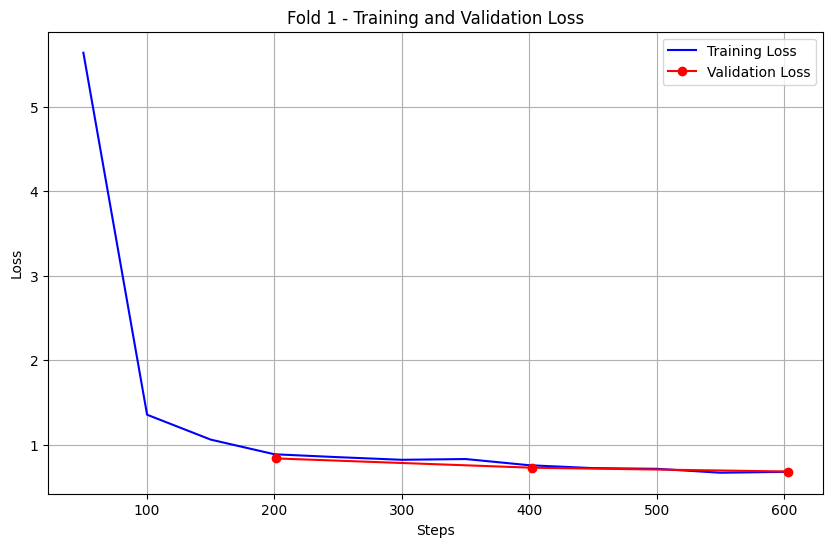

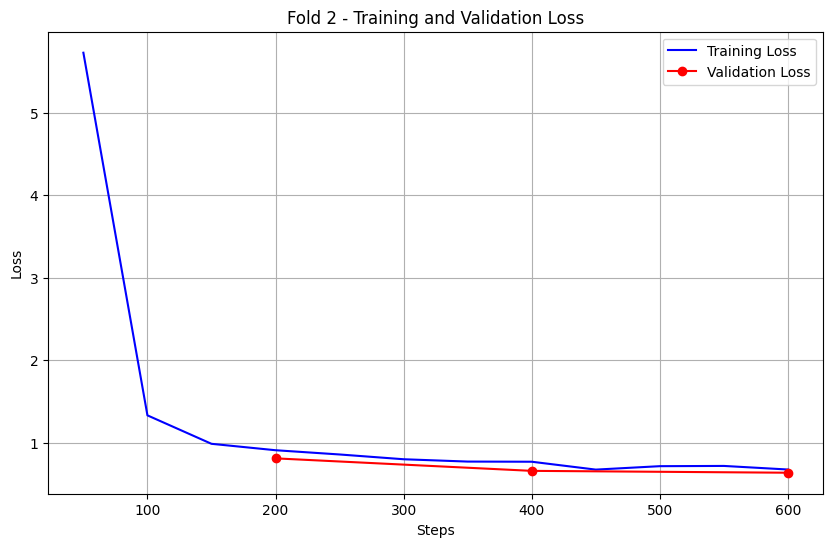

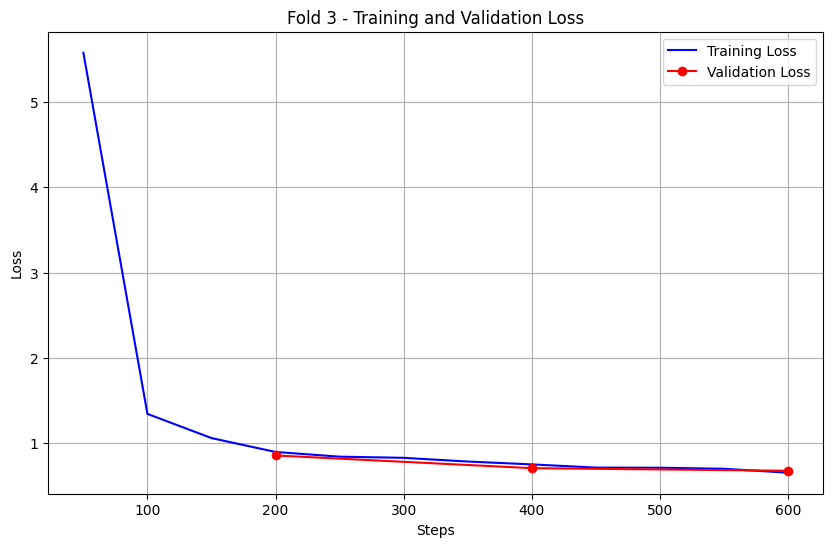

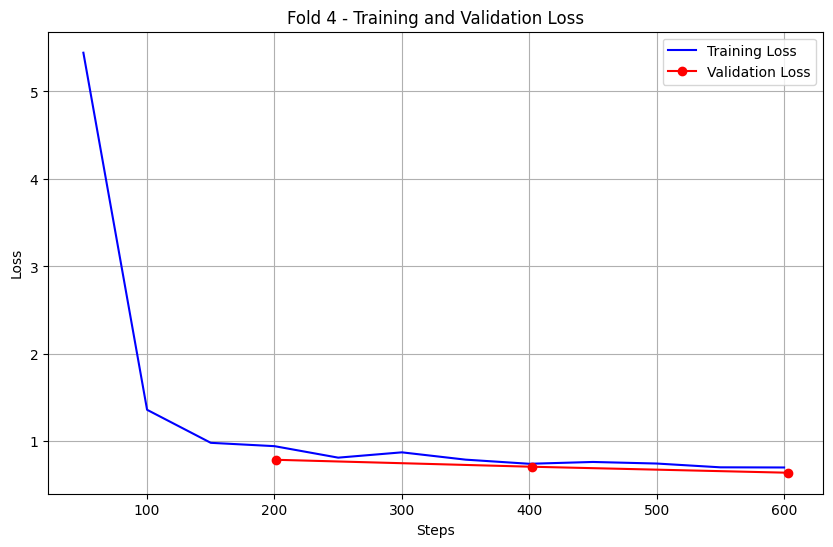

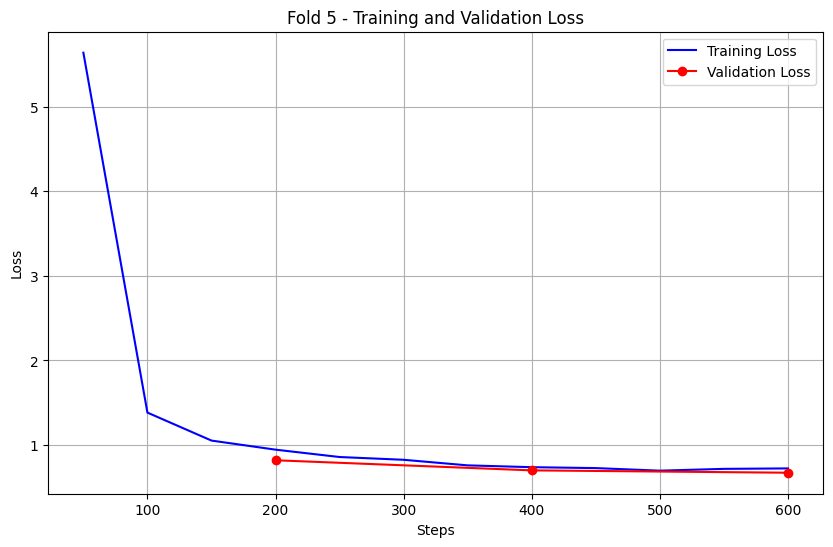

In [ ]:
import matplotlib.pyplot as plt

for fold_idx, fold_logs in enumerate(all_fold_logs):
    # Extract Training Loss
    train_steps = [x["step"] for x in fold_logs if "loss" in x and "eval_loss" not in x]
    train_losses = [x["loss"] for x in fold_logs if "loss" in x and "eval_loss" not in x]

    # Extract Validation Loss
    val_steps = [x["step"] for x in fold_logs if "eval_loss" in x]
    val_losses = [x["eval_loss"] for x in fold_logs if "eval_loss" in x]

    plt.figure(figsize=(10, 6))

    # Plotting both
    plt.plot(train_steps, train_losses, label="Training Loss", color="blue")
    plt.plot(val_steps, val_losses, label="Validation Loss", color="red", marker='o')

    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.title(f"Fold {fold_idx + 1} - Training and Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
!zip -r mbart-lora-fold-1.zip /content/mbart-lora-fold-1/
!zip -r mbart-lora-fold-2.zip /content/mbart-lora-fold-2/
!zip -r mbart-lora-fold-3.zip /content/mbart-lora-fold-3/
!zip -r mbart-lora-fold-4.zip /content/mbart-lora-fold-4/
!zip -r mbart-lora-fold-5.zip /content/mbart-lora-fold-5/

In [ ]:
from google.colab import files
files.download("mbart-lora-fold-1.zip")
files.download("mbart-lora-fold-2.zip")
files.download("mbart-lora-fold-3.zip")
files.download("mbart-lora-fold-4.zip")
files.download("mbart-lora-fold-5.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>